#PC1 — Parte III: Caso Práctico
## Procesamiento Digital de Imágenes — Capítulos 1 & 2

| Campo | Completar |
|-------|----------|
| **Alumno(a)** | Jose Alberto Quispe Zavaleta |
| **Código** | u20221c464 |
| **Fecha** | 15/04/2026 |

---

## Instrucciones

- ✏️ = celda donde debes **escribir código**.
- 💬 = celda donde debes **escribir tu análisis** (reemplaza el texto entre corchetes).
- Entrega el notebook **completamente ejecutado** con todas las salidas visibles.
- No modifiques las celdas de configuración ni la imagen base.

---

## Estructura

| Sección | Tarea | Puntos |
|---------|-------|--------|
| 0 | Setup y visualización de la imagen | — |
| 1 | Histograma inicial e interpretación | 2 pts |
| 2 | Transformaciones (brillo, umbral, zoom, filtro) | 4 pts |
| 3 | Histograma comparativo | 2 pts |
| 4 | Diagnóstico final | 2 pts |
| **Total** | | **10 pts** |

---
## Contexto del Caso

Un hospital ha digitalizado una **radiografía de tórax**. El equipo nota que la imagen tiene problemas de calidad:

- La imagen es **muy oscura** (subexpuesta)
- Hay **ruido visible** en forma de pequeñas manchas
- Las **costillas** no se distinguen claramente del tejido blando

**Tu tarea:** Procesar la imagen con las herramientas del Capítulo 2, analizar los resultados y dar un diagnóstico de si la imagen sirve para uso clínico.

In [1]:
# ============================================================
#  CELDA 0 — SETUP (NO MODIFICAR)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'axes.titlecolor': '#58a6ff',
    'axes.titlesize': 11,
})

def mostrar(imgs, titulos, figsize=(14,4)):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1: axes = [axes]
    for ax, img, t in zip(axes, imgs, titulos):
        ax.imshow(img, cmap='gray' if img.ndim==2 else None, vmin=0, vmax=255)
        ax.set_title(t); ax.axis('off')
    plt.tight_layout(); plt.show()

print('Setup listo.')

Setup listo.


Imagen: 400x320 pixeles
Media (mu): 50.9   Desv. std (sigma): 31.2


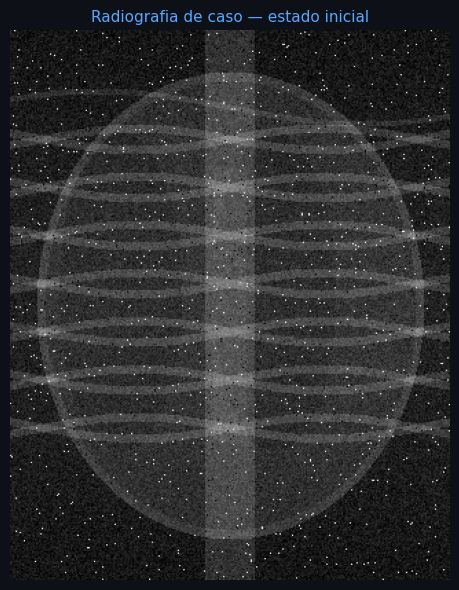

In [2]:
# ============================================================
#  CELDA 1 — IMAGEN DE CASO (NO MODIFICAR)
# ============================================================
np.random.seed(2024)
H, W = 400, 320
base = np.zeros((H, W), dtype=np.float64)
for i in range(H):
    base[i, :] = 30 + 25 * np.sin(np.pi * i / H)

yy, xx = np.ogrid[:H, :W]
cy, cx = H//2, W//2
elipse = ((yy-cy)**2/(cy*0.85)**2 + (xx-cx)**2/(cx*0.88)**2)
base[elipse < 1.0] += 40
base[(elipse >= 0.92) & (elipse < 1.0)] += 30
base[:, cx-18:cx+18] = np.clip(base[:, cx-18:cx+18] + 55, 0, 255)
base[H//4:3*H//4, cx-12:cx+12] += 20

for k in range(7):
    ry = H//5 + k*35
    for side in [-1, 1]:
        for col in range(W):
            dist = abs(col - cx)
            row = int(ry + side * 8 * np.sin(np.pi * dist / (cx * 0.85)))
            if 0 <= row < H:
                base[max(0,row-3):min(H,row+3), col] = np.clip(
                    base[max(0,row-3):min(H,row+3), col] + 60, 0, 255)

for side, lx in [(-1, cx - cx//2), (1, cx + cx//5)]:
    lmask = ((yy - cy*0.95)**2/(cy*0.58)**2 + (xx - lx)**2/(cx*0.28)**2) < 1.0
    base[lmask] = np.clip(base[lmask] - 15, 0, 255)

for xi in range(W):
    yd = int(H//7 + 12 * np.sin(np.pi * (xi - cx) / (W * 0.6)))
    if 0 <= yd < H:
        base[max(0,yd-2):min(H,yd+2), xi] = np.clip(
            base[max(0,yd-2):min(H,yd+2), xi] + 45, 0, 255)

base = base * 0.52 + 5
base = base + np.random.normal(0, 12, (H, W))
n = int(H * W * 0.008)
r1, c1 = np.random.randint(0,H,n), np.random.randint(0,W,n)
r2, c2 = np.random.randint(0,H,n), np.random.randint(0,W,n)
base[r1, c1] = 220 + np.random.randint(0, 35, n)
base[r2, c2] = np.random.randint(0, 20, n)

IMAGEN = np.clip(base, 0, 255).astype(np.uint8)

print(f'Imagen: {IMAGEN.shape[0]}x{IMAGEN.shape[1]} pixeles')
print(f'Media (mu): {IMAGEN.mean():.1f}   Desv. std (sigma): {IMAGEN.std():.1f}')
mostrar([IMAGEN], ['Radiografia de caso — estado inicial'], figsize=(5, 6))

---
## Sección 1 — Histograma Inicial
### Puntaje: 2 puntos

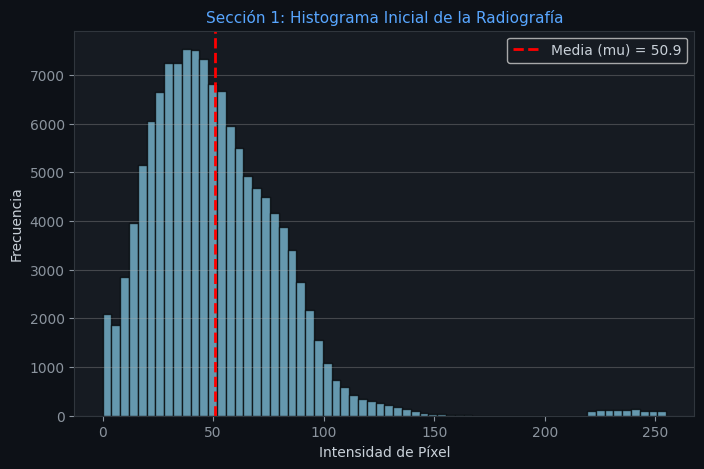

In [3]:
mu = IMAGEN.mean() # -> media

plt.figure(figsize=(8, 5))
plt.hist(IMAGEN.flatten(), bins=64, range=[0, 255], color='skyblue', edgecolor='black', alpha=0.7)

# Linea para la media
plt.axvline(mu, color='red', linestyle='dashed', linewidth=2, label=f'Media (mu) = {mu:.1f}')

plt.xlabel('Intensidad de Píxel')
plt.ylabel('Frecuencia')
plt.title('Sección 1: Histograma Inicial de la Radiografía')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### 💬 1.1 — Interpretacion del histograma

**a) La imagen esta subexpuesta, sobreexpuesta o bien expuesta? Como lo ves en el histograma?**

La imagen está subexpuesta ya que la mayoría de los píxeles están concentrados en valores de baja intensidad (menos de 50).

**b) Hay mucho o poco contraste? Que parte del histograma te lo indica?**

Hay poco contraste, el histograma lo indica precisamente al no estar distribuido uniformemente a lo largo del rango [0-255] y al haber una concentración de barras en una region estrecha (entre 0 y 100).

---
## Sección 2 — Transformaciones
### Puntaje: 4 puntos (1 pt cada una)

| Transformacion | Tipo | Puntaje |
|---------------|------|---------|
| A — Ajuste de brillo | Operacion de punto | 1 pt |
| B — Umbralización | Operacion de punto | 1 pt |
| C — Zoom sobre una zona | Operacion geometrica | 1 pt |
| D — Filtro espacial | Operacion local | 1 pt |

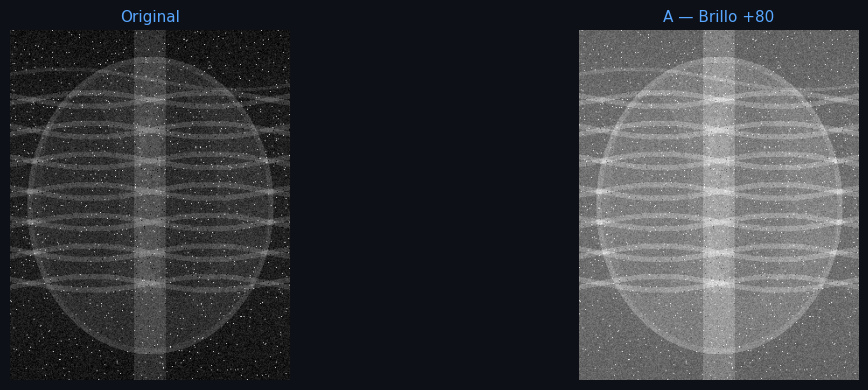

mu antes: 50.9  ->  mu despues: 130.4


In [4]:
# ============================================================
#  TRANSFORMACION A — Ajuste de brillo
#
#  Formula: g(x,y) = f(x,y) + C
#  Usa np.clip(resultado, 0, 255).astype(np.uint8)
#  Guarda en: IMG_A
# ============================================================

C = 80  # Valor elegido para compensar la subexposición

# Aplicamos la transformación de brillo
IMG_A = np.clip(IMAGEN.astype(np.float64) + C, 0, 255).astype(np.uint8)

if IMG_A is not None:
    mostrar([IMAGEN, IMG_A], ['Original', f'A — Brillo +{C}'])
    print(f'mu antes: {IMAGEN.mean():.1f}  ->  mu despues: {IMG_A.mean():.1f}')

### 💬 A — Por que elegiste ese valor de C?

Elegi C = 80 porque la imagen original tiene una media de intensidad muy baja (51 aprox), lo que indica una subexposición severa.

Al sumar 80, desplazamos la mayoría de los píxeles hacia el centro del rango dinámico (media resultante 130 aprox), permitiendo que las partes internas del cuerpo sean visibles para nosotros los humanos

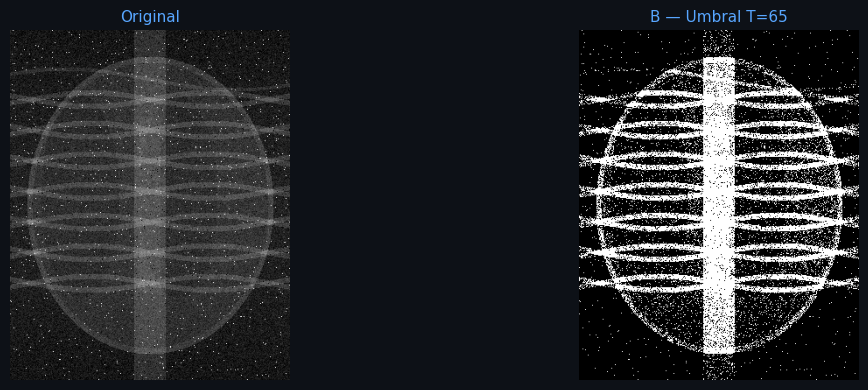

Pixeles blancos: 36,323 (28.4%)
Pixeles negros:  91,677 (71.6%)


In [5]:
# ============================================================
#  TRANSFORMACION B — Umbralización
#
#  g(x,y) = 255  si  f(x,y) >= T
#  g(x,y) = 0    si  f(x,y) < T
#  Usa np.where()
#  Guarda en: IMG_B
# ============================================================

T = 65  # Elige el umbral

# Aplicamos la umbralización usando np.where
IMG_B = np.where(IMAGEN >= T, 255, 0).astype(np.uint8)

if IMG_B is not None:
    mostrar([IMAGEN, IMG_B], ['Original', f'B — Umbral T={T}'])
    print(f'Pixeles blancos: {(IMG_B==255).sum():,} ({100*(IMG_B==255).mean():.1f}%)')
    print(f'Pixeles negros:  {(IMG_B==0).sum():,} ({100*(IMG_B==0).mean():.1f}%)')

### 💬 B — Por que elegiste ese umbral T?

Elegi T = 65 porque se encuentra justo por encima del valor medio de la imagen original.

Esto permite segmentar las estructuras más densas y brillantes del fondo más oscuro, facilitando la visualización del torax en una imagen binaria.

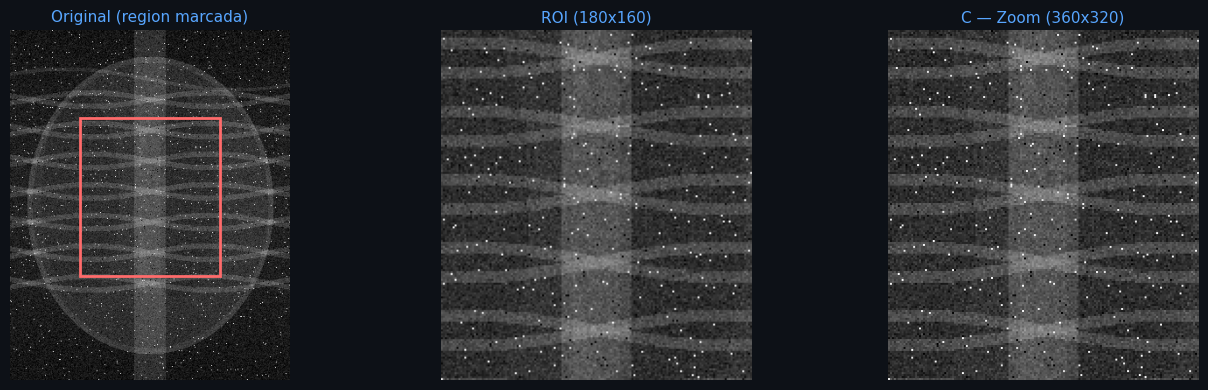

In [7]:
# ============================================================
#  TRANSFORMACION C — Zoom
#
#  1. Elige una region: roi = IMAGEN[F_INI:F_FIN, C_INI:C_FIN]
#  2. Amplía:
#     img_pil  = Image.fromarray(roi)
#     img_zoom = img_pil.resize((ancho, alto), Image.NEAREST)
#     IMG_C    = np.array(img_zoom)
#  Guarda en: IMG_C
# ============================================================

F_INI, F_FIN = 100, 280  # filas  (ej: 100, 250)
C_INI, C_FIN = 80, 240  # columnas (ej: 50, 270)


# Escribe tu codigo:
roi = IMAGEN[F_INI:F_FIN, C_INI:C_FIN]
alto, ancho = roi.shape
img_pil  = Image.fromarray(roi)
img_zoom = img_pil.resize((ancho * 2, alto * 2), Image.NEAREST)
IMG_C    = np.array(img_zoom)

if IMG_C is not None and F_INI is not None:
    import matplotlib.patches as mpatches
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(IMAGEN, cmap='gray', vmin=0, vmax=255)
    rect = mpatches.Rectangle((C_INI,F_INI), C_FIN-C_INI, F_FIN-F_INI,
                               linewidth=2, edgecolor='#FF6B6B', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title('Original (region marcada)'); axes[0].axis('off')
    axes[1].imshow(roi, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title(f'ROI ({roi.shape[0]}x{roi.shape[1]})')
    axes[1].axis('off')
    axes[2].imshow(IMG_C, cmap='gray', vmin=0, vmax=255)
    axes[2].set_title(f'C — Zoom ({IMG_C.shape[0]}x{IMG_C.shape[1]})')
    axes[2].axis('off')
    plt.tight_layout(); plt.show()

### 💬 C — Que zona ampliaste y por que?

Amplie la zona central del torax (filas 100-280, columnas 80-240). Seleccione esta region porque contiene las estructuras criticas del pecho humano.

 Con el zoom, se puede apreciar mejor la textura del ruido y la definicion de los bordes de las costillas, lo cual es vital para detectar anomalias.

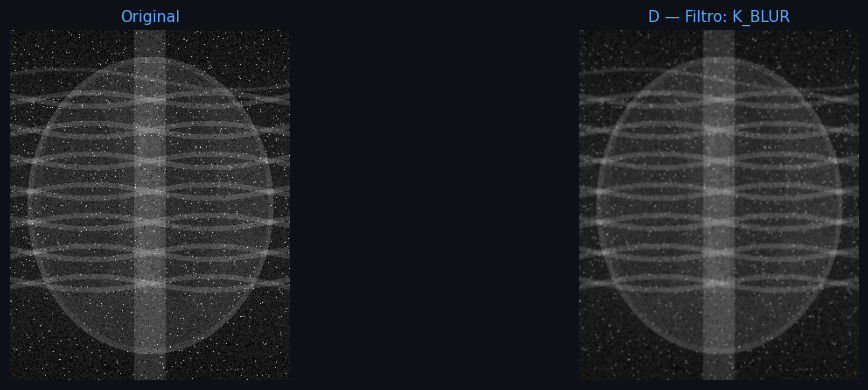

Suma del kernel: 1.0000


In [8]:
# ============================================================
#  TRANSFORMACION D — Filtro espacial
#
#  Elige UNO de los kernels y aplicalo:
#  resultado = convolve2d(IMAGEN.astype(float), kernel, mode='same', boundary='symm')
#  IMG_D = np.clip(resultado, 0, 255).astype(np.uint8)
#
#  K_BLUR  = Gaussiano 3x3  (suaviza el ruido)
#  K_SHARP = Sharpen 3x3    (enfoca detalles)
#  K_EDGES = Laplaciano 3x3 (resalta bordes)
#
#  Guarda en: IMG_D
#  Escribe el nombre elegido en: NOMBRE_FILTRO
# ============================================================

K_BLUR  = np.array([[1,2,1],[2,4,2],[1,2,1]], dtype=np.float64) / 16.0
K_SHARP = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float64)
K_EDGES = np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float64)

NOMBRE_FILTRO = 'K_BLUR'

# Escribe tu codigo:
kernel_usado = eval(NOMBRE_FILTRO)
resultado = convolve2d(IMAGEN.astype(float), kernel_usado, mode='same', boundary='symm')
IMG_D = np.clip(resultado, 0, 255).astype(np.uint8)

if IMG_D is not None:
    mostrar([IMAGEN, IMG_D], ['Original', f'D — Filtro: {NOMBRE_FILTRO}'])
    print(f'Suma del kernel: {kernel_usado.sum():.4f}')

### 💬 D — Por que elegiste ese filtro?

**a) Que hace ese filtro y que implica la suma de sus elementos?**

Elegi el filtro de K_BLUR ya que este filtro realiza un suavizado espacial reduciendo las variaciones muy bruscas de intensidad.

La suma de sus elementos será 1.0, lo que nos dice que el brillo de la imagen se mantiene constante. Esto es normalizacion.

**b) Por que es apropiado para esta imagen en particular?**

Es apropiado pq la radiografia original presentaba ruido visible. El suavizado lo que hara es ayudar a eliminar este ruido, permitiendo una vision mas limpia de la radiografia de torax.

---
## Sección 3 — Histograma Comparativo
### Puntaje: 2 puntos

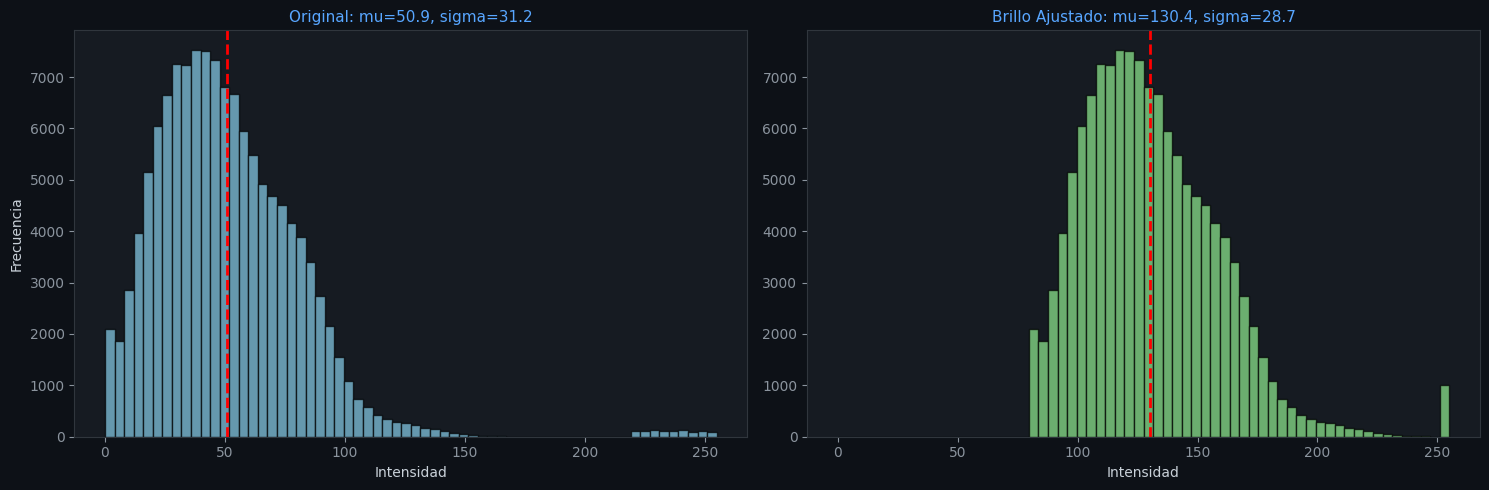

In [9]:
# ============================================================
#  SECCION 3 — Dos histogramas lado a lado
#
#  Izquierda: histograma de IMAGEN (original)
#  Derecha:   histograma de IMG_A  (con brillo ajustado)
#
#  Cada uno con 64 bins, linea en la media,
#  y en el titulo el mu y sigma.
# ============================================================

# Escribe tu codigo:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma Original
mu_orig, sigma_orig = IMAGEN.mean(), IMAGEN.std()
axes[0].hist(IMAGEN.flatten(), bins=64, range=[0, 255], color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(mu_orig, color='red', linestyle='dashed', linewidth=2)
axes[0].set_title(f'Original: mu={mu_orig:.1f}, sigma={sigma_orig:.1f}')
axes[0].set_xlabel('Intensidad'); axes[0].set_ylabel('Frecuencia')

# Histograma con Brillo (IMG_A)
mu_a, sigma_a = IMG_A.mean(), IMG_A.std()
axes[1].hist(IMG_A.flatten(), bins=64, range=[0, 255], color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(mu_a, color='red', linestyle='dashed', linewidth=2)
axes[1].set_title(f'Brillo Ajustado: mu={mu_a:.1f}, sigma={sigma_a:.1f}')
axes[1].set_xlabel('Intensidad')

plt.tight_layout()
plt.show()

### 💬 3.1 — Que cambio en el histograma?

**a) En que direccion se desplazo el histograma con la Transformacion A? Por que tiene sentido?**

El histograma se desplazo mas hacia la derecha (valores mas altos de intensidad). Esto tiene sentido porque sumamos una constante positiva (C=80), lo que incrementa el valor de cada pixel. La media paso de 51 a 131 aprximadamente.

**b) Aumento o disminuyo el contraste? Como lo ves en el histograma?**

El contraste se mantuvo similar, ya que la desviacion estandar no cambio significativamente. En el histograma se observa que la forma de la distribucion es la misma, solo que se movio de lugar en el eje X.

---
## Sección 4 — Diagnóstico Final
### Puntaje: 2 puntos

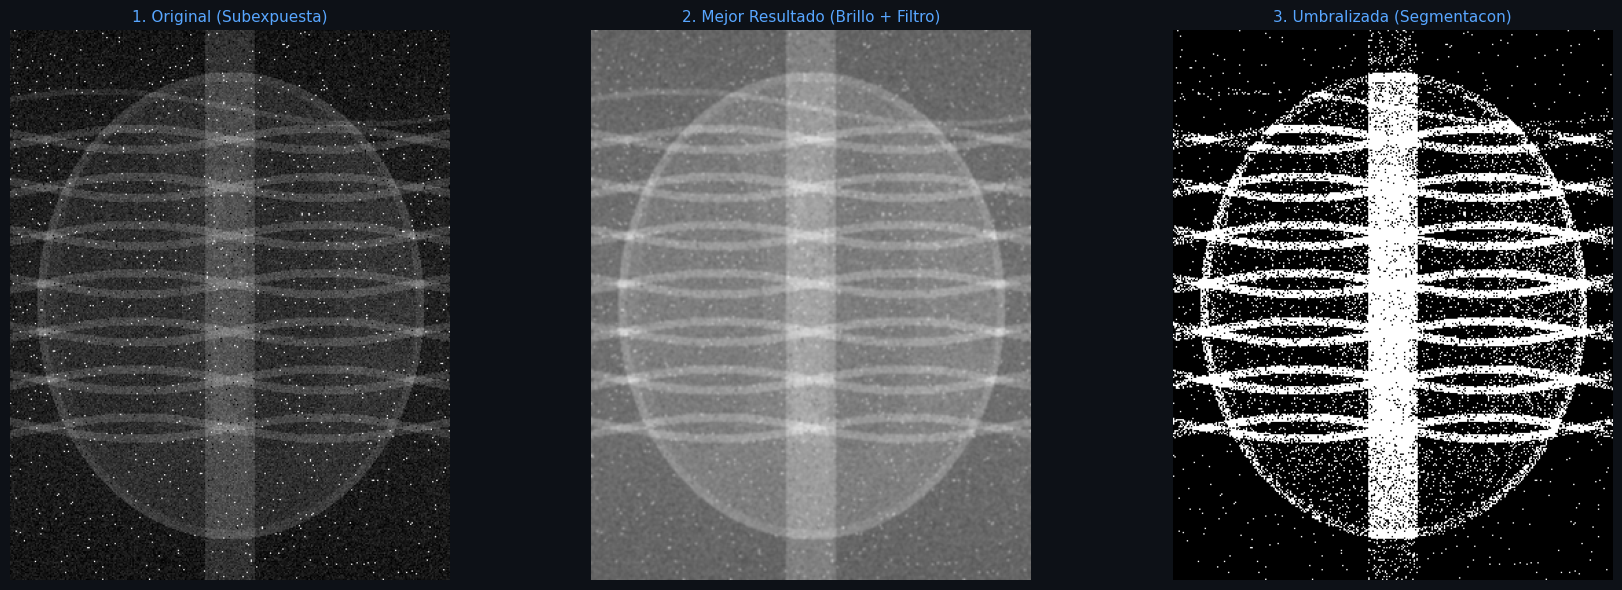

In [12]:
# ============================================================
#  SECCION 4 — Panel resumen visual
#
#  Muestra en una sola figura:
#    1. Imagen original
#    2. Tu mejor resultado (IMG_A, IMG_D, o una combinacion)
#    3. Imagen umbralizada (IMG_B)
# ============================================================

# Escribe tu codigo:

# Combinamos lo mejor: brillo (IMG_A) + filtro (IMG_D)
# Aplicamos el filtro sobre la imagen ya aclarada
resultado_suavizado = convolve2d(IMG_A.astype(float), K_BLUR, mode='same', boundary='symm')
IMG_FINAL = np.clip(resultado_suavizado, 0, 255).astype(np.uint8)

# Mostrar
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(IMAGEN, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('1. Original (Subexpuesta)')
axes[0].axis('off')

axes[1].imshow(IMG_FINAL, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('2. Mejor Resultado (Brillo + Filtro)')
axes[1].axis('off')

axes[2].imshow(IMG_B, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('3. Umbralizada (Segmentacon)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 💬 4.1 — Diagnostico

**Cual fue el problema mas importante de la imagen y como lo abordaste?**

El problema principal fue la subexposicion que la imagen tenia y el ruido. Lo pude abordar mediante un ajuste de brillo global con (C = 80) para que el histograma salga centrado y un filtro Gaussiano para suavizar las manchas de ruido.

**Cual de las transformaciones fue la mas util para el diagnostico medico? Por que?**

El ajuste de brillo fue la mas util ya que sin ella la informacion visual sería practicamente inservible para nosotros. Este filtro ayudo a que se inspeccione la imagen de una manera mas comoda.

**La imagen procesada puede usarse para diagnostico clinico o necesita retomarse? Justifica.**

La imagen mejoro en la visualizacion, pero considero que deberia retomarse. Esto debido a que la subexposicion y el ruido original degradan mucho la resolucion de contraste necesaria como para dar un diagnostico.